In [28]:
with open(r'names.txt', 'r') as f:
    words = f.read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [29]:
min([(len(w), w )for w in words])

(2, 'aj')

In [30]:
max([(len(w), w) for w in words])

(15, 'muhammadmustafa')

In [31]:
# now we will make pairs of words of 2
wb = {}
for word in words:
    chrs = ["<S>"] + list(word) + ["<E>"]
    for ch1, ch2 in zip(chrs, chrs[1:]):
        pair = (ch1 , ch2)
        wb[pair] = wb.get(pair, 0) + 1

In [32]:
wb

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [33]:
# Now we will give each character a unique value.
chars = sorted(set(''.join(words)))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [34]:
# Now we will create a tensor which will have these bi words
import torch
torch.set_printoptions(sci_mode=False) # fix the values 5.5600e+02 = 556

In [35]:
tensor = torch.zeros(27,27, dtype=torch.int32)

In [36]:
# Now we put the count to its own place.
for word in words:
    chrs = ["."] + list(word) + ["."]
    for ch1, ch2 in zip(chrs, chrs[1:]):
        p1, p2 = stoi[ch1] , stoi[ch2]
        tensor[p1,p2] +=1
tensor


tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

In [38]:
tensor[0,0].item()

0

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

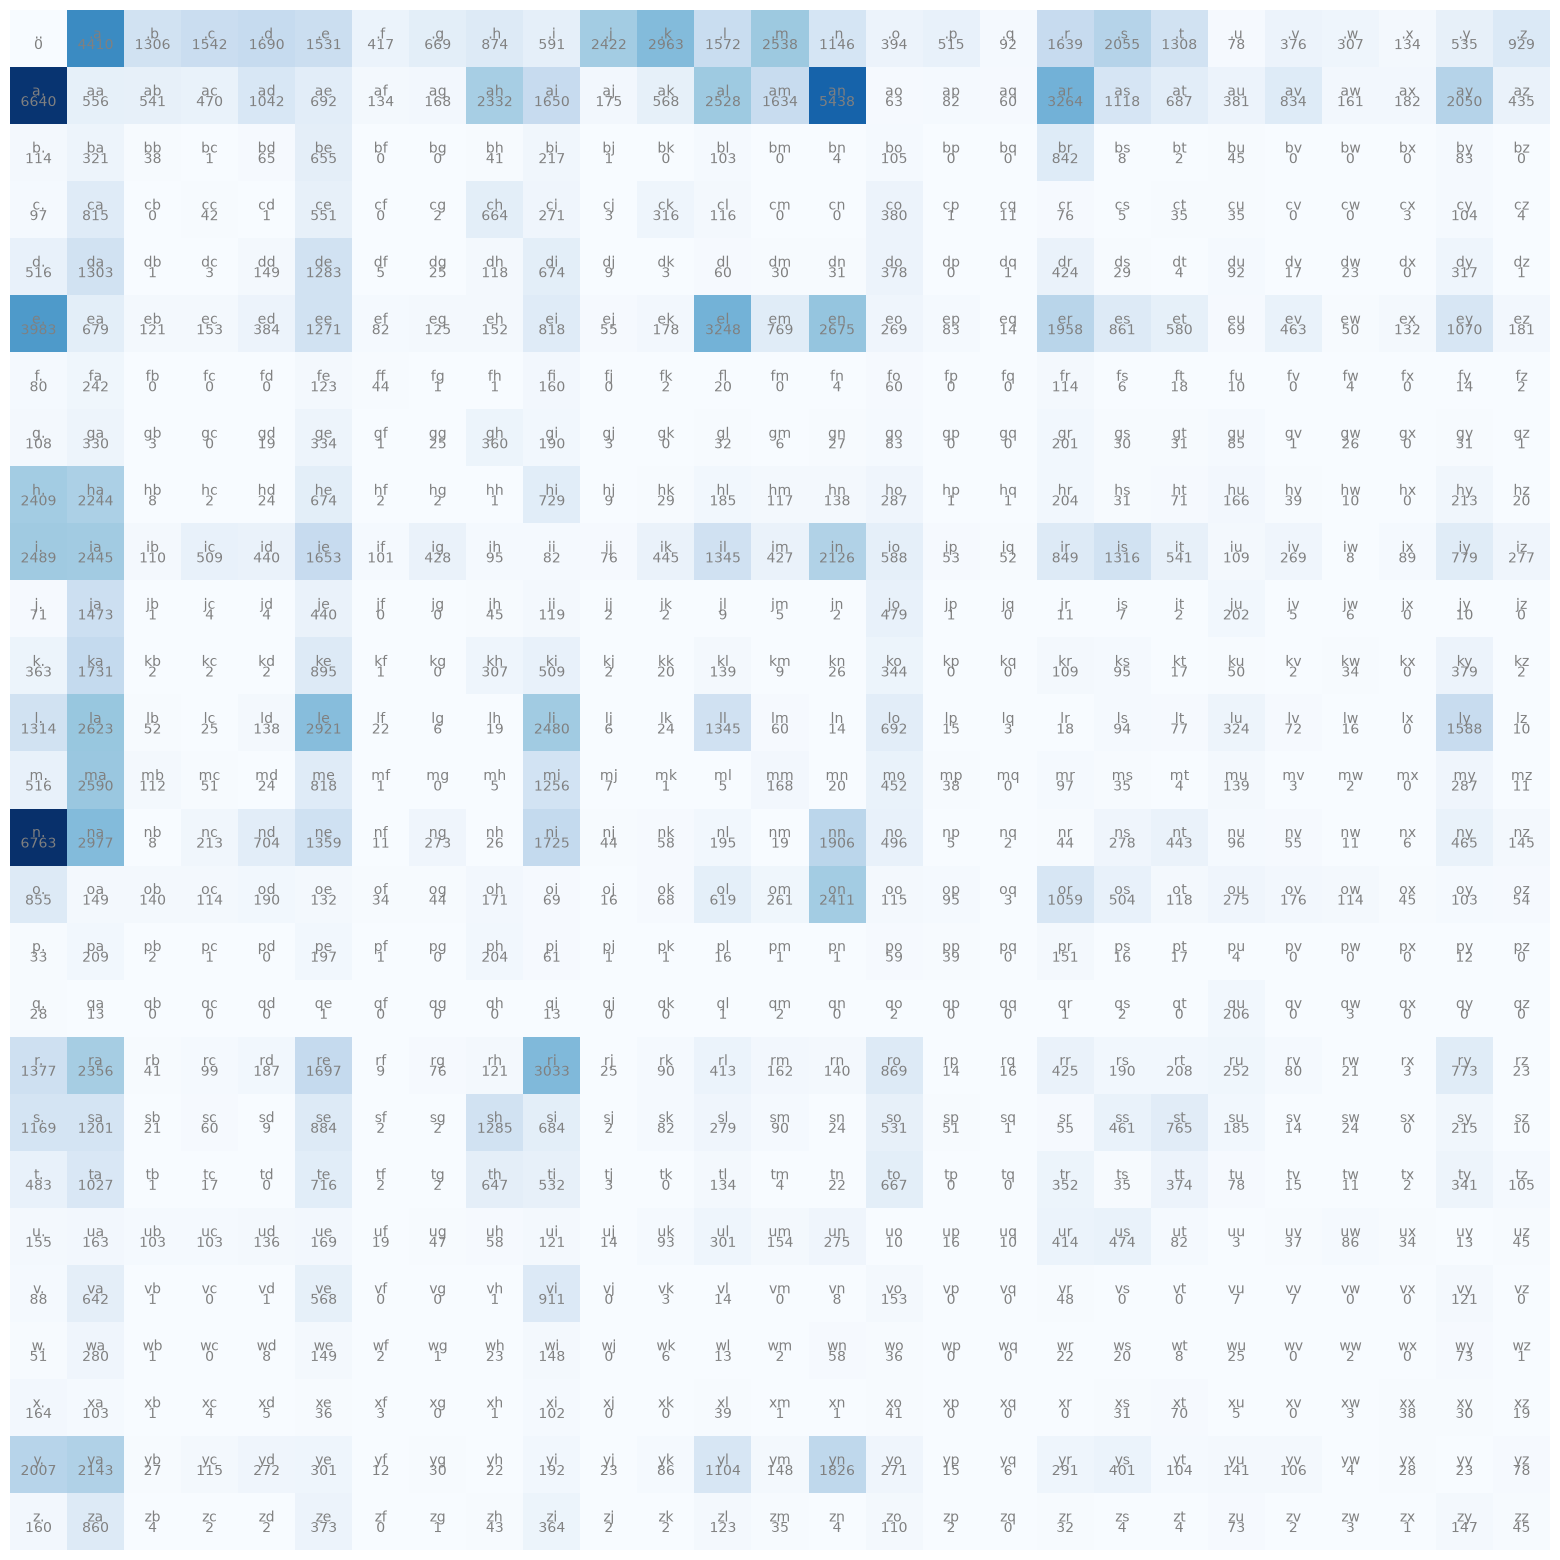

In [39]:
plt.figure(figsize=(20,20))
plt.imshow(tensor, cmap='Blues')
for i in range(27): 
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', color='gray') # put characters
        plt.text(j, i, tensor[i, j].item(), ha='center', va='top', color='gray') # put coutns of characters
plt.axis('off')

In [40]:
tensor[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [56]:
p = tensor[0].float().clone()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [58]:
# generator is use to control the randomness so that we can get predictible outcome everysingle time.
g= torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [59]:
# multinomial generate no of samples(index based) that get their proability form the input.
# This is use for model to generate 
torch.multinomial(input=p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [68]:
p = tensor[0].float().clone()
p = p / p.sum()
idx = torch.multinomial(input=p, num_samples=1, replacement=True, generator=g).item()
itos[idx]

'u'

In [45]:
# (27, 27) / (27, 1) start from right, if the dimesions are equal, or one is 1 dim or non of them exist then only the broadcasting will work.
# (23,23) / (23) # will work
# (23,23) / (23,1) # will work
# (23,23) / (22,1) # will not work

# we do this to make sure that we don't get infinity for those proability that have 0 count. This is called Model smoothing.
P = (tensor+1).float().clone()
# use inplace operation uses less memory and is faster
P /= P.sum(1, keepdim=True) # here you should always keepdim=True, otherwise you will get an error.
P[0].sum()

tensor(1.)

In [46]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(5):
    idx = 0
    out = []
    while True:
        p = P[idx]
        idx = torch.multinomial(input=p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [ ]:
# pytorch broadcasting, where the dimension should be equal, 1 or desn't exists.
# Other than these condition you will get error.
x = torch.rand(5,2,3,1)
y = torch.rand(2,1,1)
(x/y).shape

torch.Size([5, 2, 3, 1])

* A function is monotonic, if it moves consistently in one direction—it either never decreases or never increases as the input values grow. 
(https://statisticsbyjim.com/glossary/monotonic-function/)

* A log is a monotonic function as it always increase, and its derivate is also positive.

In [ ]:
# GOAL: maximize the likelihood of thee data w.r.t models parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negitive log likelihood
# equivalent to minimizing the average of the negitive log likelihood.

# log(a*b*c) = log(a) + log(b) + log(c)

In [49]:
log_likehood = 0.0
n = 0
# for word in words:
for word in ['saadx']:
    chrs = ["."] + list(word) + ["."]
    for ch1, ch2 in zip(chrs, chrs[1:]):
        # pair = (ch1 , ch2)
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        log_prob = torch.log(prob)
        log_likehood += log_prob
        n+=1
        print(f"{ch1}{ch2} {prob:.4f} {log_prob:.4f}")

print(f'{log_likehood=}')
nnl = -log_likehood
print(f"{nnl=}")
print(f"loss= {(nnl/n):.4f}")

.s 0.0641 -2.7468
sa 0.1478 -1.9119
aa 0.0164 -4.1090
ad 0.0308 -3.4817
dx 0.0002 -8.6167
x. 0.2279 -1.4788
log_likehood=tensor(-22.3449)
nnl=tensor(22.3449)
loss= 3.7242


In [81]:
# Creating the training dataset.
xs, ys = [], []

for word in words[:1]:
    chrs = ["."] + list(word) + ["."]
    for ch1, ch2 in zip(chrs, chrs[1:]):
        p1, p2 = stoi[ch1] , stoi[ch2]
        xs.append(p1)
        ys.append(p2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [82]:
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [89]:
import torch.nn.functional as F

xenc= F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

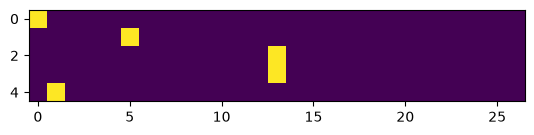

In [87]:
plt.imshow(xenc)

In [93]:
xenc.shape

torch.Size([5, 27])

In [113]:
generator = torch.Generator().manual_seed(2147483647)
weights = torch.randn(27,27, generator=generator)
logits = xenc @ weights # log counts
counts = logits.exp() # using exponent to make every value positive. just like N.
probs = counts / counts.sum(1, keepdim=True) # getting proability for each value
# btw these last 2 lines are same working principle behind "Softmax" funtion.

In [114]:
probs.shape

torch.Size([5, 27])

In [115]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

In [116]:
# ----------- Optimization --------------- #

In [118]:
xs

tensor([ 0,  5, 13, 13,  1])

In [119]:
ys

tensor([ 5, 13, 13,  1,  0])

In [188]:
# randomly initalize 27 neurons weights, each neuron recieve 27 inputs.
generator = torch.Generator().manual_seed(2147483647)
weights = torch.randn(27,27, generator=generator, requires_grad=True)

In [ ]:
# forward pass

logits = xenc @ weights 
counts = logits.exp() 
probs = counts / counts.sum(1, keepdim=True)

# + 1*(weights**2).mean()  works like a regularization that tries to make weights approch zero.
# This works like model smoothing make the proabilites unifrom
loss = -probs[torch.arange(0,5), ys].log().mean() + 1*(weights**2).mean() 
print("loss= ",loss.item()) # negitive average log likelyhood

loss=  3.7693049907684326


In [190]:
# backward pass
weights.grad = None # we are making the already existing gradients to zero.
loss.backward()

In [191]:
# updating parameters

# weights.data += 0.1 * weights.grad <-- This is also possible, but sure you know when your using this.
with torch.no_grad(): 
    weights += -0.1 * weights.grad

##### **Creating a proper flow**


In [240]:
# Creating the training dataset.
xs, ys = [], []

for word in words:
    chrs = ["."] + list(word) + ["."]
    for ch1, ch2 in zip(chrs, chrs[1:]):
        p1, p2 = stoi[ch1] , stoi[ch2]
        xs.append(p1)
        ys.append(p2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
nums = xs.nelement()
print(f"Number of examples: {nums}")

xenc= F.one_hot(xs, num_classes=27).float()
generator = torch.Generator().manual_seed(2147483647)
weights = torch.randn(27,27, generator=generator, requires_grad=True)

Number of examples: 228146


In [ ]:
epochs = 100
for i in range(epochs):
    
    # forward pass
    logits = xenc @ weights 
    counts = logits.exp() 
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(nums), ys].log().mean() + 1*(weights**2).mean()
    print(f"{i+1} loss= ",loss.item()) # negitive average log likelyhood

    # backward pass
    weights.grad = None # we are making the already existing gradients to zero.
    loss.backward()

    # updating parameters
    with torch.no_grad(): 
        weights += -50 * weights.grad

# print(f"{epochs} loss= ",loss.item()) # negitive average log likelyhood

1 loss=  2.7212941646575928
2 loss=  2.679508686065674
3 loss=  2.6509652137756348
4 loss=  2.6295406818389893
5 loss=  2.6127216815948486
6 loss=  2.599076747894287
7 loss=  2.587731122970581
8 loss=  2.5781164169311523
9 loss=  2.5698444843292236
10 loss=  2.5626394748687744
11 loss=  2.556297540664673
12 loss=  2.550666570663452
13 loss=  2.5456278324127197
14 loss=  2.5410900115966797
15 loss=  2.5369784832000732
16 loss=  2.533234119415283
17 loss=  2.5298092365264893
18 loss=  2.526662588119507
19 loss=  2.523761749267578
20 loss=  2.5210773944854736
21 loss=  2.518587112426758
22 loss=  2.5162694454193115
23 loss=  2.5141072273254395
24 loss=  2.512085437774658
25 loss=  2.510190486907959
26 loss=  2.508410930633545
27 loss=  2.506736993789673
28 loss=  2.5051584243774414
29 loss=  2.5036685466766357
30 loss=  2.5022592544555664
31 loss=  2.500924825668335
32 loss=  2.499659299850464
33 loss=  2.498457431793213
34 loss=  2.497314214706421
35 loss=  2.4962260723114014
36 loss=  2

In [ ]:
# Creating names form the Neural Net.

g = torch.Generator().manual_seed(2147483647)

for _ in range(5):
    idx = 0
    out = []
    while True:
        # p = probs[idx]
        xenc_test = F.one_hot(xs[idx], num_classes=27).float()
        logits = xenc_test @ weights
        count = logits.exp()
        p = count / count.sum() 
        
        idx = torch.multinomial(input=p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break
    print(''.join(out))

cexba.
mhalkuraiiaziayhnekljlmjtraierlknan.
kh.
dr.
snaiiaebatrhr.
